**IMPORTS**

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

MASTER_SEED = 42 #for reproducible results

**CONSTANTS**

In [103]:
#Dose levels (mg oral morphine equivalent per decision step)
#Five discrete levels - from no medication to maximum safe dose
#Discretisation follows standard clinical practice

DOSE_MG = {0: 0, 1: 5, 2: 10, 3: 15, 4:20}
N_ACTIONS = 5

#Hard safety limit: maximum opioid in any 24-hour window
#Grounded in standard clinical safety guidelines
MAX_DOSE_24H = 80 #mg

#Episode structure
STEP_HOURS = 4 #each decision point is 4 hours apart
MAX_STEPS = 30  # 30 steps x 4h = 120h (typical VOC hospitalisation)
WINDOW_STEPS = 6 # 6 steps = 4h = 24h rolling does window




**PATIENT PROFILE**

In [106]:
@dataclass
class PatientProfile:
    """
    Fixed biological characteristics for one synthetic patient. 
    Different patients have different pain sensitivity, drug response,
    and tolerance dynamics. This is the interpatient variability described in Sagi et al. (2021).
    
    """

    patient_id         :int 
    patient_type       :int            #0 = mild, 1 = moderate, 2 = severe
    pain_sensitivity   :float          #how fast pain rises without treatment (0-1)
    drug_response      :float          #how well opioids reduce pain (0-1)
    tolerance_rate     :float          #how fast tolerance builds per dose
    tolerance_decay    :float          #how fast tolerence fades without dosing
    baseline_pain      :float          #the "resting" pain level during the crisis

**PATIENT SAMPLER**

In [109]:
def sample_patient(patient_id: int, rng: np.random.Generator) -> PatientProfile:
    """
    Samples one synthetic patient from the population.
    Population distribution: 40% mild, 40% moderate, 20% severe
    Severe patients are rarer, but are overrepresented in hospital admissions, 
    consistent with Brousseau et al. (2010)
    """

    r = rng.random()

    if r < 0.4:
        #mild phenotype
        ptype = 0
        pain_sensitivity = rng.uniform(0.3, 0.6)
        drug_response = rng.uniform(0.5, 0.8)
        tolerance_rate = rng.uniform(0.005, 0.015)   
        tolerance_decay = rng.uniform(0.03, 0.06)
        baseline_pain = rng.uniform(3.0, 5.0)
    
    elif r < 0.8:
        #moderate phenotype
        ptype = 1
        pain_sensitivity = rng.uniform(0.5, 0.8)
        drug_response = rng.uniform(0.35, 0.60)
        tolerance_rate = rng.uniform(0.010, 0.025)
        tolerance_decay = rng.uniform(0.02, 0.04)
        baseline_pain = rng.uniform(5.0, 7.5)
    
    else:
        #severe phenotype
        ptype = 2
        pain_sensitivity = rng.uniform(0.7, 1.0)
        drug_response = rng.uniform(0.20, 0.45)
        tolerance_rate = rng.uniform(0.015, 0.035)
        tolerance_decay = rng.uniform(0.01, 0.03)
        baseline_pain = rng.uniform(7.0, 9.5)

    return PatientProfile(
        patient_id = patient_id,
        patient_type = ptype,
        pain_sensitivity = pain_sensitivity,
        drug_response = drug_response,
        tolerance_rate = tolerance_rate,
        tolerance_decay = tolerance_decay,
        baseline_pain = baseline_pain,
    )


**STATE**

In [112]:
@dataclass
class State:
    """
    The full observable state at one decision point.
    This is what the agent (or doctor) sees before making a dosing decision.
    """
    pain_score   :float          #(0-10 scale)
    tolerance    :float          #0-1 (0 = no tolerance, 1 = full tolerance)
    cumulative_dose : float      #mg given in the last 24h
    time_since_crisis : float    #hours since crisis onset
    patient_type: int            # 0, 1, or 2

    def to_array(self) -> np.ndarray:
        """
        Converts state to a normalised numpy array for the neural network. 
        Everything is scaled to roughly [0,1], this is because neural networks train more 
        efficiently when they are on the same scale. Standard practice in Deep RL. 

        Source: Sutton & Barto (2018), chapter 9 - feature representation
        """
        return np.array([
            self.pain_score/10,
            self.tolerance,
            self.cumulative_dose / MAX_DOSE_24H,
            self.time_since_crisis / (MAX_STEPS * STEP_HOURS),
            self.patient_type /2.0,
            
        ], dtype=np.float32)
    

**THE SIMULATOR ITSELF**

In [123]:
class SCDSimulator:
    """
    Simulates a vaso-occlusive crisis and the effect of opioid dosing.

    Implements the MDP transition funCtion P(S'|s, a) and reward R (S, A, S')
    described in Chapter 3, Sections 3.3.2 and 3.3.3
    """

    def __init__(self, seed:int = MASTER_SEED):
        self.rng = np.random.default_rng(seed)
        self.patient:Optional[PatientProfile]  =None
        self.state: Optional[State]        = None
        self.step_count : int  = 0
        self.dose_history: List[float] = []

    def reset(self, patient_id: int = 0,
              patient: Optional[PatientProfile] = None) -> State:
        """Start a new episode (new hospitalisation)."""
        self.patient = patient or sample_patient(patient_id, self.rng)
        self.step_count = 0
        self.dose_history = [0.0] * WINDOW_STEPS

        #Crisis has just begun - so pain starts high but not necessarily at peak
        initial_pain = float(np.clip(
            self.patient.baseline_pain + self.rng.uniform(0.5, 1.5), 0.0, 10.0))
        
        self.state = State(
            pain_score = initial_pain,
            tolerance = self.rng.uniform(0.0, 0.2), #assumes some pre-existing tolerance
            cumulative_dose = 0.0,
            time_since_crisis = 0.0,
            patient_type = self.patient.patient_type,
        )
        return self.state


    def get_safe_actions(self, state: State) -> List[int]:
        """
        Returns actions that satisfy all hard safety constraints.
        Implements Section 3.3.3 of the methodology

        Hard constraints:
        1. 24h cumulative dose must not exceed MAX_DOSE_24H
        2. High doses blocked when pain is already well controlled (<3), prevents
           over sedation.
        3. Maximum dose blocked when tolerance is very high risk (0.8)
           diminishing returns+side effect risk
        """
        safe = []
        for action in range(N_ACTIONS):
            dose = DOSE_MG[action]

            if state.cumulative_dose + dose >MAX_DOSE_24H:
                continue
            
            if state.pain_score<3.0 and action >=3:
                continue

            if state.tolerance>0.8 and action ==4:
                continue

            safe.append(action)


        return safe if safe else [0] #action 0 (no dose) is always available


    def is_safe(self, state: State, action: int) -> bool:
        return action in self.get_safe_actions(state)


    def step(self, action: int) -> Tuple[State, float, bool, dict]:
        """
        Apply a dosing action. Advance time by 4 hours.
        Returns (next_state, reward, done, info).
        """
    
        assert self.state is not None, "Call reset() first"
    
        dose_mg = DOSE_MG[action]
        safety_violation = not self.is_safe(self.state, action)
    
        # ── TRANSITION: natural pain worsening ───────────────────────────
        # During a VOC, pain rises without adequate medication.
        # Rate depends on patient's pain sensitivity and how far pain is
        # from their baseline level. Noise captures biological variability.
        natural_worsening = (
            self.patient.pain_sensitivity *
            max(0, self.patient.baseline_pain - self.state.pain_score * 0.7) *
            0.18 + self.rng.normal(0, 0.20)
        )
    
        # ── TRANSITION: drug effect ───────────────────────────────────────
        # Effectiveness is reduced by tolerance.
        # Effect is also modulated by current pain level — at high pain,
        # opioids work at near full power; as pain reduces toward zero,
        # marginal effect diminishes. This reflects pharmacodynamic ceiling
        # effects described in Angst & Clark (2006).
        effective_response = (
            self.patient.drug_response * (1.0 - 0.6 * self.state.tolerance)
        )
        pain_factor = self.state.pain_score / 10.0
        scaling = {0: 7.0, 1: 7.5, 2: 9.5}[self.patient.patient_type]
        drug_effect = effective_response * (dose_mg / 20.0) * scaling * pain_factor
    
        new_pain = float(np.clip(
            self.state.pain_score + natural_worsening - drug_effect,
            0.0, 10.0
        ))
    
        # ── TRANSITION: tolerance dynamics ────────────────────────────────
        # Tolerance builds with each dose, decays slowly without dosing.
        if dose_mg > 0:
            # Tolerance builds with dosing.
            # For severe patients, a partial passive decay is applied during dosing
            # to prevent unrealistic saturation over 120h — reflecting clinical
            # opioid rotation practices (Ballas et al., 2012).
            # Mild and moderate patients have low enough tolerance rates that
            # saturation is not a risk over this episode length.
            if self.patient.patient_type == 2:  # severe only
                tol_delta = (self.patient.tolerance_rate * (dose_mg / 20.0)
                             - self.patient.tolerance_decay * 0.4)
            else:
                tol_delta = self.patient.tolerance_rate * (dose_mg / 20.0)
        else:
            # No dosing — tolerance fades for all patient types
            tol_delta = -self.patient.tolerance_decay


    
        new_tolerance = float(np.clip(
            self.state.tolerance + tol_delta, 0.0, 1.0
        ))
    
        # ── TRANSITION: rolling 24h dose window ──────────────────────────
        self.dose_history.append(dose_mg)
        self.dose_history.pop(0)
        new_cumulative = float(sum(self.dose_history))
    
        # ── REWARD ────────────────────────────────────────────────────────
        # Goal: reduce pain, avoid over-medication, never violate safety.
        # Safety violations receive a large negative signal — the agent
        # must learn these are never acceptable regardless of pain benefit.
        pain_reward       =  (10.0 - new_pain) / 10.0
        dose_penalty      = -0.15 * (dose_mg / 20.0)
        tolerance_penalty = -0.2  * new_tolerance
        safety_penalty    = -2.0  if safety_violation else 0.0
    
        reward = pain_reward + dose_penalty + tolerance_penalty + safety_penalty
    
        # ── NEXT STATE ────────────────────────────────────────────────────
        self.step_count += 1
        self.state = State(
            pain_score        = new_pain,
            tolerance         = new_tolerance,
            cumulative_dose   = new_cumulative,
            time_since_crisis = self.step_count * STEP_HOURS,
            patient_type      = self.patient.patient_type,
        )
    
        done = (self.step_count >= MAX_STEPS) or (new_pain <= 1.5)
    
        info = {
            "safety_violation": safety_violation,
            "dose_mg"         : dose_mg,
            "step"            : self.step_count,
        }
    
        return self.state, reward, done, info










**SANITY CHECK**


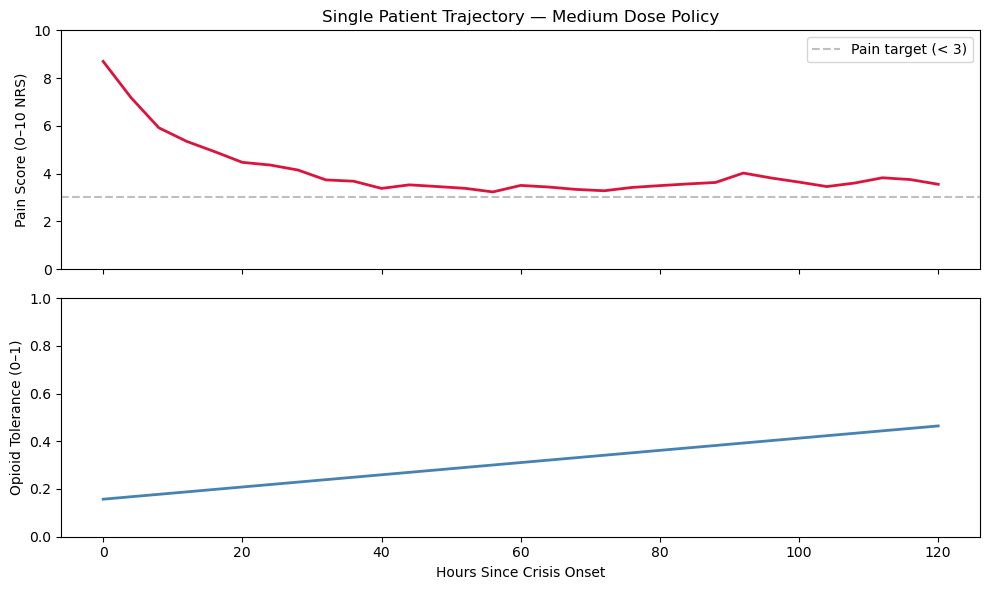

Patient type: Moderate
Drug response: 0.56
Final pain: 3.55
Final tolerance: 0.46
Total steps: 30


In [126]:
# Run one episode with a fixed "always give medium dose" policy
# and plot what happens to pain and tolerance over time

sim    = SCDSimulator(seed=MASTER_SEED)
state  = sim.reset(patient_id=0)

pain_over_time      = [state.pain_score]
tolerance_over_time = [state.tolerance]
dose_over_time      = []
hours               = [0]

done = False
while not done:
    action = 2  # always medium dose (10mg) for this sanity check
    state, reward, done, info = sim.step(action)
    pain_over_time.append(state.pain_score)
    tolerance_over_time.append(state.tolerance)
    dose_over_time.append(info["dose_mg"])
    hours.append(state.time_since_crisis)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(hours, pain_over_time, color="crimson", linewidth=2)
axes[0].axhline(y=3, color="grey", linestyle="--", alpha=0.5, label="Pain target (< 3)")
axes[0].set_ylabel("Pain Score (0–10 NRS)")
axes[0].set_ylim(0, 10)
axes[0].legend()
axes[0].set_title("Single Patient Trajectory — Medium Dose Policy")

axes[1].plot(hours, tolerance_over_time, color="steelblue", linewidth=2)
axes[1].set_ylabel("Opioid Tolerance (0–1)")
axes[1].set_xlabel("Hours Since Crisis Onset")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("sanity_check_trajectory.png", dpi=150)
plt.show()

print(f"Patient type: {['Mild','Moderate','Severe'][sim.patient.patient_type]}")
print(f"Drug response: {sim.patient.drug_response:.2f}")
print(f"Final pain: {pain_over_time[-1]:.2f}")
print(f"Final tolerance: {tolerance_over_time[-1]:.2f}")
print(f"Total steps: {sim.step_count}")

**SANITY CHECK FOR THREE PATIENT TYPES**

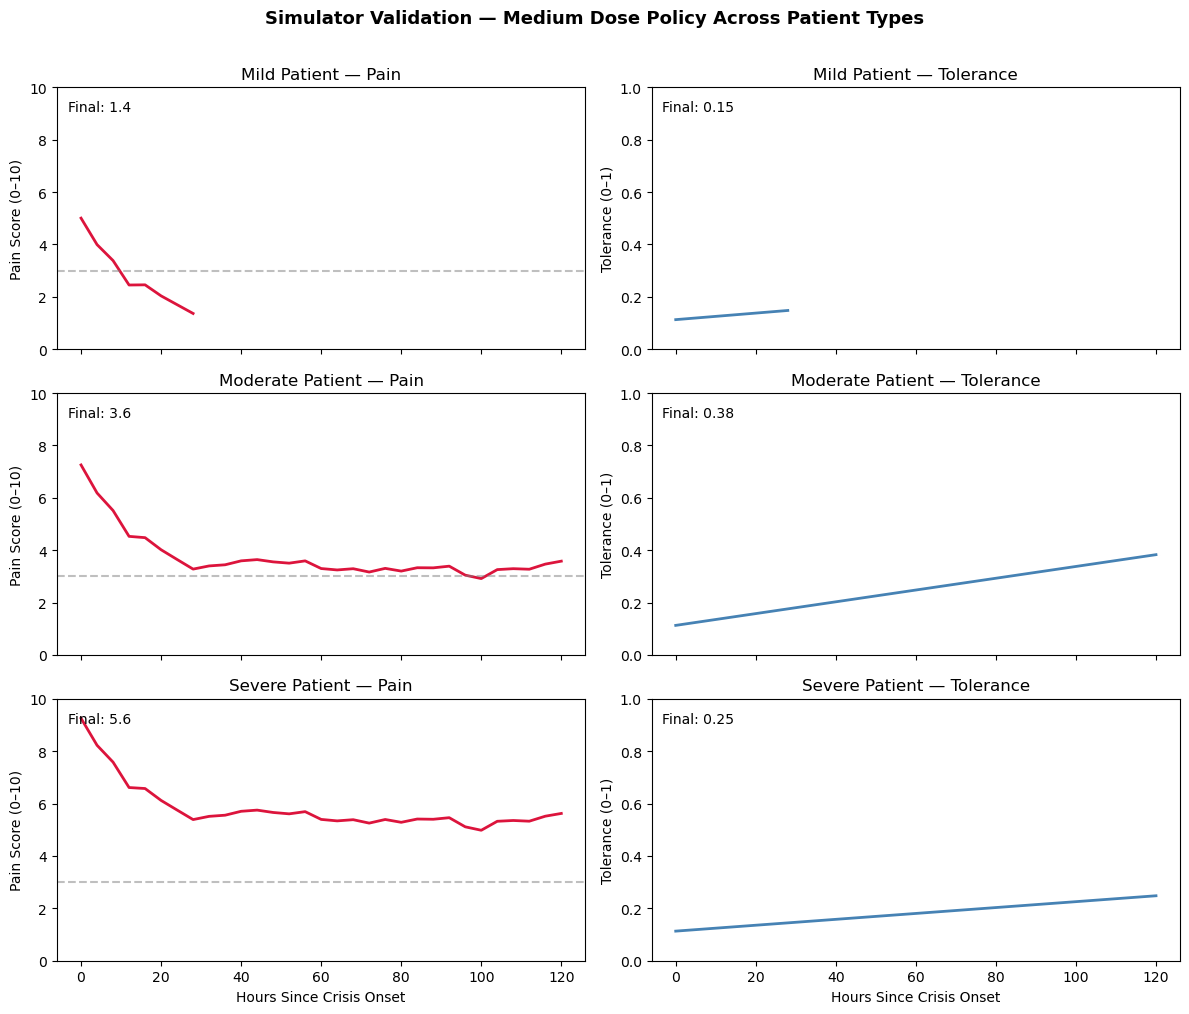

In [129]:
# Test all three patient types to confirm the simulator 
# behaves correctly across the population

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
patient_labels = ["Mild", "Moderate", "Severe"]
colours = ["steelblue", "crimson"]

rng_test = np.random.default_rng(seed=99)

for row, ptype in enumerate([0, 1, 2]):

    # Force a patient of the specific type we want to test
    if ptype == 0:
        test_patient = PatientProfile(
            patient_id=ptype, patient_type=0,
            pain_sensitivity=0.45, drug_response=0.65,
            tolerance_rate=0.01, tolerance_decay=0.045,
            baseline_pain=4.0
        )
    elif ptype == 1:
        test_patient = PatientProfile(
            patient_id=ptype, patient_type=1,
            pain_sensitivity=0.65, drug_response=0.48,
            tolerance_rate=0.018, tolerance_decay=0.03,
            baseline_pain=6.25
        )
    else:
        test_patient = PatientProfile(
            patient_id=ptype, patient_type=2,
            pain_sensitivity=0.85, drug_response=0.32,
            tolerance_rate=0.025, tolerance_decay=0.02,
            baseline_pain=8.25
        )

    sim = SCDSimulator(seed=99)
    state = sim.reset(patient_id=ptype, patient=test_patient)

    pain_history = [state.pain_score]
    tol_history  = [state.tolerance]
    hours        = [0]

    done = False
    while not done:
        action = 2  # medium dose throughout
        state, reward, done, info = sim.step(action)
        pain_history.append(state.pain_score)
        tol_history.append(state.tolerance)
        hours.append(state.time_since_crisis)

    # Pain plot
    axes[row, 0].plot(hours, pain_history, color="crimson", linewidth=2)
    axes[row, 0].axhline(y=3, color="grey", linestyle="--", alpha=0.5)
    axes[row, 0].set_ylabel("Pain Score (0–10)")
    axes[row, 0].set_ylim(0, 10)
    axes[row, 0].set_title(f"{patient_labels[ptype]} Patient — Pain")
    axes[row, 0].text(0.02, 0.95, f"Final: {pain_history[-1]:.1f}",
                      transform=axes[row,0].transAxes, verticalalignment='top')

    # Tolerance plot
    axes[row, 1].plot(hours, tol_history, color="steelblue", linewidth=2)
    axes[row, 1].set_ylabel("Tolerance (0–1)")
    axes[row, 1].set_ylim(0, 1)
    axes[row, 1].set_title(f"{patient_labels[ptype]} Patient — Tolerance")
    axes[row, 1].text(0.02, 0.95, f"Final: {tol_history[-1]:.2f}",
                      transform=axes[row,1].transAxes, verticalalignment='top')

axes[2, 0].set_xlabel("Hours Since Crisis Onset")
axes[2, 1].set_xlabel("Hours Since Crisis Onset")

plt.suptitle("Simulator Validation — Medium Dose Policy Across Patient Types",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("three_patient_validation.png", dpi=150)
plt.show() 

In [201]:
# ─────────────────────────────────────────────────────────────
# MIXED BEHAVIOUR POLICY
# ─────────────────────────────────────────────────────────────
# Generates the offline dataset using a richer mixture of policies
# to provide CQL with broader distributional coverage.
#
# Policy composition:
#   70% standard clinical protocol (the conservative baseline)
#   30% reactive heuristic        (tolerance-aware dosing)
#   15% epsilon-random exploration on top of the above
#
# This addresses the distributional support problem described in
# Levine et al. (2020): the offline agent can only learn well in
# regions of the state-action space that the behaviour policy
# explored. By mixing policies, we broaden that support.

def mixed_behaviour_policy(state: State, sim: SCDSimulator,
                            rng: np.random.Generator) -> int:
    """
    Mixed behaviour policy combining standard protocol and
    reactive heuristic with epsilon-random exploration.

    This is used purely for offline dataset generation —
    it is not one of the evaluation baselines.
    """
    safe = sim.get_safe_actions(state)

    # 15% epsilon-random exploration
    if rng.random() < 0.15:
        return int(rng.choice(safe))

    # 30% reactive heuristic, 70% standard protocol
    if rng.random() < 0.30:
        return reactive_heuristic_policy(state, sim, rng)
    else:
        return standard_protocol_policy(state, sim, rng)

In [205]:
# ─────────────────────────────────────────────────────────────
# BEHAVIOUR POLICY — Standard Clinical Protocol
# ─────────────────────────────────────────────────────────────
# This is the rule-based policy that generates the offline dataset.
# It mimics a realistic but suboptimal clinical protocol:
#   - High pain (>= 7): give high dose (action 3)
#   - Moderate pain (5-7): give medium dose (action 2)
#   - Mild pain (3-5): give low dose (action 1)
#   - Well controlled (< 3): no dose (action 0)
# 
# Crucially, it does NOT adapt to tolerance or cumulative dose history
# beyond the hard safety constraints — this is exactly the limitation
# that motivates learning a better policy.
#
# Small epsilon-random chance of deviating from the rule — this ensures
# the dataset has some coverage of non-greedy actions, which is important
# for offline RL to learn from.
# Source: Levine et al. (2020) — behaviour policy coverage

def standard_protocol(state: State, sim: SCDSimulator,
                       rng: np.random.Generator,
                       epsilon: float = 0.15) -> int:
    """
    Rule-based standard dosing protocol with epsilon-random exploration.
    Returns a safe action index.
    """
    safe_actions = sim.get_safe_actions(state)

    # Epsilon-random: occasionally pick a random safe action
    if rng.random() < epsilon:
        return rng.choice(safe_actions)

    # Rule-based dose selection
    if state.pain_score >= 7.0:
        preferred = 3   # high dose (15mg)
    elif state.pain_score >= 5.0:
        preferred = 2   # medium dose (10mg)
    elif state.pain_score >= 3.0:
        preferred = 1   # low dose (5mg)
    else:
        preferred = 0   # no dose

    # Fall back to closest safe action if preferred is blocked
    if preferred in safe_actions:
        return preferred
    else:
        # Pick the safe action closest to preferred
        return min(safe_actions, key=lambda a: abs(a - preferred))


# ─────────────────────────────────────────────────────────────
# OFFLINE DATASET GENERATOR
# ─────────────────────────────────────────────────────────────

def generate_offline_dataset(n_episodes: int = 2000,
                              seed: int = MASTER_SEED,
                              policy_fn=None) -> pd.DataFrame:
    """
    Generates the offline dataset by running the standard protocol
    for n_episodes and recording every transition.

    Each row is one transition: (s, a, r, s', done)
    This is the dataset the CQL agent will learn from.

    Returns a pandas DataFrame with one row per timestep.
    """
    rng = np.random.default_rng(seed)
    sim = SCDSimulator(seed=seed + 1)  # different seed from rng

    records = []

    for episode in range(n_episodes):
        state = sim.reset(patient_id=episode)

        done = False
        while not done:
            # Record current state
            s = state.to_array()

            # Behaviour policy selects action
            if policy_fn is None:
                action = standard_protocol(state, sim, rng)
            else:
                action = policy_fn(state, sim, rng)

            # Step the simulator
            next_state, reward, done, info = sim.step(action)
            ns = next_state.to_array()

            # Store transition
            records.append({
                # State components (raw, for inspection)
                "pain_score"        : state.pain_score,
                "tolerance"         : state.tolerance,
                "cumulative_dose"   : state.cumulative_dose,
                "time_since_crisis" : state.time_since_crisis,
                "patient_type"      : state.patient_type,

                # Normalised state vector (for the neural network)
                "s0": s[0], "s1": s[1], "s2": s[2], "s3": s[3], "s4": s[4],

                # Action taken
                "action": action,
                "dose_mg": info["dose_mg"],

                # Reward received
                "reward": reward,

                # Normalised next state vector
                "ns0": ns[0], "ns1": ns[1], "ns2": ns[2],
                "ns3": ns[3], "ns4": ns[4],

                # Terminal flag
                "done": done,

                # Metadata (useful for analysis)
                "episode"          : episode,
                "safety_violation" : info["safety_violation"],
            })

            state = next_state

        if (episode + 1) % 500 == 0:
            print(f"Generated {episode + 1}/{n_episodes} episodes...")

    df = pd.DataFrame(records)
    print(f"\nDataset complete.")
    print(f"  Total transitions : {len(df)}")
    print(f"  Episodes          : n_episodes")
    print(f"  Safety violations : {df['safety_violation'].sum()}")
    print(f"  Mean pain score   : {df['pain_score'].mean():.2f}")
    print(f"  Action distribution:")
    for a in range(N_ACTIONS):
        pct = (df['action'] == a).mean() * 100
        print(f"    Action {a} ({DOSE_MG[a]:2d}mg): {pct:.1f}%")

    return df


print("Generating offline dataset with mixed behaviour policy...")
dataset = generate_offline_dataset(
    n_episodes=2000,
    seed=MASTER_SEED,
    policy_fn=mixed_behaviour_policy
)

dataset.to_csv("scd_offline_dataset.csv", index=False)
print(f"\nSaved to scd_offline_dataset.csv")

Generating offline dataset with mixed behaviour policy...
Generated 500/2000 episodes...
Generated 1000/2000 episodes...
Generated 1500/2000 episodes...
Generated 2000/2000 episodes...

Dataset complete.
  Total transitions : 59462
  Episodes          : n_episodes
  Safety violations : 0
  Mean pain score   : 4.07
  Action distribution:
    Action 0 ( 0mg): 20.5%
    Action 1 ( 5mg): 48.0%
    Action 2 (10mg): 23.6%
    Action 3 (15mg): 5.5%
    Action 4 (20mg): 2.4%

Saved to scd_offline_dataset.csv


In [207]:
dataset = pd.read_csv("scd_offline_dataset.csv")

print("Mean pain score by patient type:")
print(dataset.groupby('patient_type')['pain_score'].mean().round(2))

print("\nMean episode length by patient type:")
ep_len = dataset.groupby('episode').size()
pt = dataset.groupby('episode')['patient_type'].first()
for t in [0, 1, 2]:
    eps = pt[pt == t].index
    print(f"  Type {t}: {ep_len[eps].mean():.1f} steps")

print("\nEpisodes ending early (pain resolved before 30 steps):")
ep_len_all = dataset.groupby('episode').size()
print(f"  Early: {(ep_len_all < 30).sum()}")
print(f"  Full:  {(ep_len_all == 30).sum()}")

Mean pain score by patient type:
patient_type
0    2.96
1    4.26
2    5.72
Name: pain_score, dtype: float64

Mean episode length by patient type:
  Type 0: 29.3 steps
  Type 1: 30.0 steps
  Type 2: 30.0 steps

Episodes ending early (pain resolved before 30 steps):
  Early: 40
  Full:  1960


In [219]:
# ─────────────────────────────────────────────────────────────
# BASELINE POLICIES
# ─────────────────────────────────────────────────────────────

def random_policy(state: State, sim: SCDSimulator,
                  rng: np.random.Generator) -> int:
    """
    Selects uniformly at random from safe actions.
    Represents the performance floor — any learned policy should beat this.
    """
    safe = sim.get_safe_actions(state)
    return int(rng.choice(safe))


def standard_protocol_policy(state: State, sim: SCDSimulator,
                              rng: np.random.Generator) -> int:
    """
    Deterministic rule-based standard dosing protocol.
    Represents current clinical practice.
    Pain >= 7  -> high dose (15mg)
    Pain 5-7   -> medium dose (10mg)
    Pain 3-5   -> low dose (5mg)
    Pain < 3   -> no dose
    No epsilon exploration — pure protocol, no randomness.
    """
    safe = sim.get_safe_actions(state)

    if state.pain_score >= 7.0:
        preferred = 3
    elif state.pain_score >= 5.0:
        preferred = 2
    elif state.pain_score >= 3.0:
        preferred = 1
    else:
        preferred = 0

    if preferred in safe:
        return preferred
    return min(safe, key=lambda a: abs(a - preferred))


def reactive_heuristic_policy(state: State, sim: SCDSimulator,
                               rng: np.random.Generator) -> int:
    """
    Tolerance-aware oracle baseline. Uses ground-truth tolerance
    state to demonstrate the upper bound of what tolerance-aware
    rule-based care could achieve given perfect information.
    
    Note: this is an oracle baseline — real clinicians do not have
    direct access to a quantified tolerance value. The CQL agent
    must learn to match this performance using only observable
    state variables.
    """
    safe = sim.get_safe_actions(state)
    adjusted_pain = state.pain_score * (1.0 + 0.5 * state.tolerance)

    if adjusted_pain >= 8.5:
        preferred = 4
    elif adjusted_pain >= 6.5:
        preferred = 3
    elif adjusted_pain >= 4.5:
        preferred = 2
    elif adjusted_pain >= 2.5:
        preferred = 1
    else:
        preferred = 0

    if preferred in safe:
        return preferred
    return min(safe, key=lambda a: abs(a - preferred))
# ─────────────────────────────────────────────────────────────
# EVALUATION FUNCTION
# ─────────────────────────────────────────────────────────────

def evaluate_policy(policy_fn, policy_name: str,
                    n_episodes: int = 500,
                    seed: int = MASTER_SEED + 99) -> dict:
    """
    Evaluates a policy over n_episodes and returns aggregate metrics.

    Uses a fresh simulator seeded independently from the training
    simulator — these are test patients the policy has never seen.

    Metrics:
      mean_pain        : average pain score across all timesteps
      final_pain       : average pain score at end of each episode
      safety_violations: total hard constraint violations
      mean_cum_dose    : average 24h cumulative dose load
      pct_at_target    : % of timesteps where pain < 3
      mean_ep_length   : average episode length in steps
      mean_pain_mild   : mean pain for mild patients only
      mean_pain_mod    : mean pain for moderate patients only
      mean_pain_sev    : mean pain for severe patients only
    """
    rng = np.random.default_rng(seed)
    sim = SCDSimulator(seed=seed + 1)

    all_pain        = []
    final_pains     = []
    safety_viols    = 0
    all_doses       = []
    steps_at_target = 0
    total_steps     = 0
    ep_lengths      = []
    pain_by_type    = {0: [], 1: [], 2: []}

    for episode in range(n_episodes):
        state = sim.reset(patient_id=episode)
        ep_pain = []
        done = False

        while not done:
            action = policy_fn(state, sim, rng)
            next_state, reward, done, info = sim.step(action)

            ep_pain.append(state.pain_score)
            all_doses.append(state.cumulative_dose)
            pain_by_type[state.patient_type].append(state.pain_score)

            if info["safety_violation"]:
                safety_viols += 1
            if state.pain_score < 3.0:
                steps_at_target += 1
            total_steps += 1

            state = next_state

        all_pain.extend(ep_pain)
        final_pains.append(ep_pain[-1])
        ep_lengths.append(len(ep_pain))

    return {
        "policy"          : policy_name,
        "mean_pain"       : round(np.mean(all_pain), 3),
        "final_pain"      : round(np.mean(final_pains), 3),
        "safety_violations": safety_viols,
        "mean_cum_dose"   : round(np.mean(all_doses), 2),
        "pct_at_target"   : round(steps_at_target / total_steps * 100, 1),
        "mean_ep_length"  : round(np.mean(ep_lengths), 1),
        "mean_pain_mild"  : round(np.mean(pain_by_type[0]), 3) if pain_by_type[0] else 0,
        "mean_pain_mod"   : round(np.mean(pain_by_type[1]), 3) if pain_by_type[1] else 0,
        "mean_pain_sev"   : round(np.mean(pain_by_type[2]), 3) if pain_by_type[2] else 0,
    }


# ─────────────────────────────────────────────────────────────
# RUN ALL BASELINES
# ─────────────────────────────────────────────────────────────

print("Evaluating baseline policies (500 episodes each)...\n")

baseline_results = []

for policy_fn, name in [
    (random_policy,             "Random Policy"),
    (standard_protocol_policy,  "Standard Protocol"),
    (reactive_heuristic_policy, "Reactive Heuristic"),
]:
    print(f"  Running: {name}...")
    result = evaluate_policy(policy_fn, name, n_episodes=500)
    baseline_results.append(result)
    print(f"    Mean pain:        {result['mean_pain']}")
    print(f"    Final pain:       {result['final_pain']}")
    print(f"    % at target:      {result['pct_at_target']}%")
    print(f"    Safety violations:{result['safety_violations']}")
    print(f"    Mean cum. dose:   {result['mean_cum_dose']} mg")
    print(f"    By type — mild: {result['mean_pain_mild']}, "
          f"mod: {result['mean_pain_mod']}, sev: {result['mean_pain_sev']}")
    print()

print("=" * 55)
print(f"{'Policy':<22} {'MeanPain':>9} {'FinalPain':>10} {'AtTarget%':>10} {'SafeViols':>10}")
print("=" * 55)
for r in baseline_results:
    print(f"{r['policy']:<22} {r['mean_pain']:>9} {r['final_pain']:>10} "
          f"{r['pct_at_target']:>9}% {r['safety_violations']:>10}")
print("=" * 55)

Evaluating baseline policies (500 episodes each)...

  Running: Random Policy...
    Mean pain:        3.914
    Final pain:       3.127
    % at target:      35.7%
    Safety violations:0
    Mean cum. dose:   40.4 mg
    By type — mild: 2.602, mod: 3.784, sev: 5.801

  Running: Standard Protocol...
    Mean pain:        4.252
    Final pain:       4.069
    % at target:      18.9%
    Safety violations:0
    Mean cum. dose:   29.34 mg
    By type — mild: 3.167, mod: 4.575, sev: 5.75

  Running: Reactive Heuristic...
    Mean pain:        3.842
    Final pain:       3.588
    % at target:      32.6%
    Safety violations:0
    Mean cum. dose:   34.71 mg
    By type — mild: 2.809, mod: 4.165, sev: 5.496

Policy                  MeanPain  FinalPain  AtTarget%  SafeViols
Random Policy              3.914      3.127      35.7%          0
Standard Protocol          4.252      4.069      18.9%          0
Reactive Heuristic         3.842      3.588      32.6%          0


In [215]:
# ─────────────────────────────────────────────────────────────
# TRAIN / VALIDATION / TEST SPLIT
# ─────────────────────────────────────────────────────────────
# Split the 2,000 episodes into three disjoint sets:
#   Train      (70%): 1,400 episodes — used to train the CQL agent
#   Validation (15%): 300 episodes  — used to select hyperparameters
#   Test       (15%): 300 episodes  — used ONLY for final reporting
#
# This separation ensures that hyperparameter tuning decisions
# do not leak information about the final evaluation cohort,
# addressing a standard methodological requirement for credible
# offline RL evaluation (Levine et al., 2020).

dataset = pd.read_csv("scd_offline_dataset.csv")

# Split episode indices reproducibly
all_episodes = np.arange(2000)
split_rng = np.random.default_rng(MASTER_SEED)
split_rng.shuffle(all_episodes)

train_eps = set(all_episodes[:1400])
val_eps   = set(all_episodes[1400:1700])
test_eps  = set(all_episodes[1700:])

# Filter dataset by episode membership
train_data = dataset[dataset["episode"].isin(train_eps)].reset_index(drop=True)
val_data   = dataset[dataset["episode"].isin(val_eps)].reset_index(drop=True)
test_data  = dataset[dataset["episode"].isin(test_eps)].reset_index(drop=True)

print(f"Dataset split:")
print(f"  Train:      {len(train_eps):>4} episodes, {len(train_data):>6} transitions")
print(f"  Validation: {len(val_eps):>4} episodes, {len(val_data):>6} transitions")
print(f"  Test:       {len(test_eps):>4} episodes, {len(test_data):>6} transitions")

# Convert TRAIN data to tensors (this is what the agent learns from)
s_cols  = ["s0", "s1", "s2", "s3", "s4"]
ns_cols = ["ns0", "ns1", "ns2", "ns3", "ns4"]

states      = torch.FloatTensor(train_data[s_cols].values).to(DEVICE)
actions     = torch.LongTensor(train_data["action"].values).to(DEVICE)
rewards     = torch.FloatTensor(train_data["reward"].values).to(DEVICE)
next_states = torch.FloatTensor(train_data[ns_cols].values).to(DEVICE)
dones       = torch.FloatTensor(train_data["done"].values).to(DEVICE)

print(f"\nTrain tensors loaded: {states.shape[0]:,} transitions ready for CQL training")

Dataset split:
  Train:      1400 episodes,  41738 transitions
  Validation:  300 episodes,   8883 transitions
  Test:        300 episodes,   8841 transitions

Train tensors loaded: 41,738 transitions ready for CQL training


In [189]:
# ─────────────────────────────────────────────────────────────
# SPLIT-AWARE EVALUATION
# ─────────────────────────────────────────────────────────────
# This evaluation function uses a deterministic patient seed
# scheme so that the same set of patients is used consistently
# across val/test runs and across all policies being compared.

def evaluate_policy_on_split(policy_fn, policy_name: str,
                              episode_ids: list,
                              seed_offset: int = 100000) -> dict:
    """
    Evaluates a policy on a fixed set of episode IDs.
    Each episode_id is used to seed both patient sampling and the simulator,
    ensuring the same patients are encountered across all policies.
    """
    rng = np.random.default_rng(seed_offset)
    all_pain        = []
    final_pains     = []
    safety_viols    = 0
    all_doses       = []
    steps_at_target = 0
    total_steps     = 0
    ep_lengths      = []
    pain_by_type    = {0: [], 1: [], 2: []}

    for ep_id in episode_ids:
        # Use the episode_id to seed the simulator deterministically
        sim = SCDSimulator(seed=int(ep_id) + seed_offset)
        state = sim.reset(patient_id=int(ep_id))

        ep_pain = []
        done = False

        while not done:
            action = policy_fn(state, sim, rng)
            next_state, reward, done, info = sim.step(action)

            ep_pain.append(state.pain_score)
            all_doses.append(state.cumulative_dose)
            pain_by_type[state.patient_type].append(state.pain_score)

            if info["safety_violation"]:
                safety_viols += 1
            if state.pain_score < 3.0:
                steps_at_target += 1
            total_steps += 1

            state = next_state

        all_pain.extend(ep_pain)
        final_pains.append(ep_pain[-1])
        ep_lengths.append(len(ep_pain))

    return {
        "policy"           : policy_name,
        "n_episodes"       : len(episode_ids),
        "mean_pain"        : round(np.mean(all_pain), 3),
        "final_pain"       : round(np.mean(final_pains), 3),
        "safety_violations": safety_viols,
        "mean_cum_dose"    : round(np.mean(all_doses), 2),
        "pct_at_target"    : round(steps_at_target / total_steps * 100, 1),
        "mean_ep_length"   : round(np.mean(ep_lengths), 1),
        "mean_pain_mild"   : round(np.mean(pain_by_type[0]), 3) if pain_by_type[0] else 0,
        "mean_pain_mod"    : round(np.mean(pain_by_type[1]), 3) if pain_by_type[1] else 0,
        "mean_pain_sev"    : round(np.mean(pain_by_type[2]), 3) if pain_by_type[2] else 0,
    }


val_episode_ids  = sorted(val_eps)
test_episode_ids = sorted(test_eps)

print(f"Evaluation splits ready:")
print(f"  Validation: {len(val_episode_ids)} episodes")
print(f"  Test:       {len(test_episode_ids)} episodes")

Evaluation splits ready:
  Validation: 300 episodes
  Test:       300 episodes


In [141]:
# ─────────────────────────────────────────────────────────────
# CQL AGENT — CONSERVATIVE Q-LEARNING FOR OFFLINE RL
# ─────────────────────────────────────────────────────────────
# Implements the Conservative Q-Learning algorithm of
# Kumar et al. (2020) for offline reinforcement learning.
# The agent learns from the fixed offline dataset and never
# interacts with the simulator during training.

import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds for reproducibility
torch.manual_seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

STATE_DIM  = 5   # dimensionality of normalised state vector
N_ACTIONS  = 5   # number of discrete dose levels
DEVICE     = torch.device("cpu")  # CPU is fine for this scale

print(f"Using device: {DEVICE}")
print(f"State dimension: {STATE_DIM}")
print(f"Action space size: {N_ACTIONS}")

Using device: cpu
State dimension: 5
Action space size: 5


In [142]:
# ─────────────────────────────────────────────────────────────
# Q-NETWORK ARCHITECTURE
# ─────────────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """
    Approximates the Q-function Q(s, a) for all actions simultaneously.

    Architecture: two hidden layers of 128 neurons with ReLU activation.
    Input:  normalised state vector (5 dimensions)
    Output: Q-value estimates for all 5 actions

    This architecture follows the deep Q-network design of
    Mnih et al. (2015), simplified for the scale of this problem.
    """

    def __init__(self, state_dim: int = STATE_DIM,
                 n_actions: int = N_ACTIONS,
                 hidden_dim: int = 128):
        super(QNetwork, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# Instantiate Q-network and target network
q_net     = QNetwork().to(DEVICE)
target_net = QNetwork().to(DEVICE)

# Target network starts as an exact copy of Q-network
target_net.load_state_dict(q_net.state_dict())
target_net.eval()  # target network is never trained directly

print("Q-Network architecture:")
print(q_net)
print(f"\nTotal parameters: {sum(p.numel() for p in q_net.parameters()):,}")

Q-Network architecture:
QNetwork(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

Total parameters: 17,925


In [143]:
# # ─────────────────────────────────────────────────────────────
# # DATASET PREPARATION
# # ─────────────────────────────────────────────────────────────
# # Load the offline dataset and convert to PyTorch tensors.
# # Each row is one transition: (s, a, r, s', done)

# dataset = pd.read_csv("scd_offline_dataset.csv")

# # State columns (normalised)
# s_cols  = ["s0", "s1", "s2", "s3", "s4"]
# ns_cols = ["ns0", "ns1", "ns2", "ns3", "ns4"]

# # Convert to tensors
# states      = torch.FloatTensor(dataset[s_cols].values).to(DEVICE)
# actions     = torch.LongTensor(dataset["action"].values).to(DEVICE)
# rewards     = torch.FloatTensor(dataset["reward"].values).to(DEVICE)
# next_states = torch.FloatTensor(dataset[ns_cols].values).to(DEVICE)
# dones       = torch.FloatTensor(dataset["done"].values).to(DEVICE)

# print(f"Dataset loaded:")
# print(f"  States shape:      {states.shape}")
# print(f"  Actions shape:     {actions.shape}")
# print(f"  Rewards shape:     {rewards.shape}")
# print(f"  Next states shape: {next_states.shape}")
# print(f"  Dones shape:       {dones.shape}")
# print(f"  Reward range:      [{rewards.min():.3f}, {rewards.max():.3f}]")

Dataset loaded:
  States shape:      torch.Size([59331, 5])
  Actions shape:     torch.Size([59331])
  Rewards shape:     torch.Size([59331])
  Next states shape: torch.Size([59331, 5])
  Dones shape:       torch.Size([59331])
  Reward range:      [-0.062, 0.887]


In [191]:
# ─────────────────────────────────────────────────────────────
# CQL TRAINING LOOP
# ─────────────────────────────────────────────────────────────
# Trains the Q-network using the Conservative Q-Learning loss.
#
# The loss has two components:
#
# 1. Bellman loss (standard Q-learning)
#    Minimises the difference between predicted Q-values and
#    bootstrapped target Q-values. This is what all Q-learning
#    algorithms do. Source: Sutton & Barto (2018), Chapter 6.
#
# 2. CQL penalty (conservative regularisation)
#    Pushes down Q-values for out-of-distribution actions and
#    pushes up Q-values for actions seen in the dataset.
#    This prevents overestimation of unseen actions.
#    Source: Kumar et al. (2020), Equation 4.
#
# Hyperparameters:
GAMMA        = 0.99    # discount factor: how much future rewards matter
                       # 0.99 means the agent is far-sighted
LR           = 3e-4    # learning rate for Adam optimiser
BATCH_SIZE   = 256     # number of transitions per training step
CQL_ALPHA    = 0.07     # weight of the CQL penalty term
                       # higher = more conservative
TARGET_UPDATE = 100    # update target network every N steps
N_EPOCHS     = 150     # number of full passes through the dataset
# ─────────────────────────────────────────────────────────────

optimiser = optim.Adam(q_net.parameters(), lr=LR)

n_samples   = len(states)
n_batches   = n_samples // BATCH_SIZE
global_step = 0

# Track losses for plotting later
bellman_losses = []
cql_penalties  = []
total_losses   = []

print(f"Training CQL agent...")
print(f"  Dataset size:    {n_samples:,} transitions")
print(f"  Batch size:      {BATCH_SIZE}")
print(f"  Batches/epoch:   {n_batches}")
print(f"  Total epochs:    {N_EPOCHS}")
print(f"  CQL alpha:       {CQL_ALPHA}")
print(f"  Discount (γ):    {GAMMA}")
print()

for epoch in range(N_EPOCHS):
    # Shuffle dataset each epoch
    perm = torch.randperm(n_samples)

    epoch_bellman = []
    epoch_cql     = []
    epoch_total   = []

    for batch_idx in range(n_batches):
        # Sample a mini-batch
        idx = perm[batch_idx * BATCH_SIZE : (batch_idx + 1) * BATCH_SIZE]

        s  = states[idx]
        a  = actions[idx]
        r  = rewards[idx]
        ns = next_states[idx]
        d  = dones[idx]

        # ── BELLMAN LOSS ───────────────────────────────────────
        # Current Q-values for the actions that were actually taken
        q_values     = q_net(s)                        # shape: (batch, 5)
        q_taken      = q_values.gather(1, a.unsqueeze(1)).squeeze(1)
        # q_taken[i] = Q(s_i, a_i) for each transition i

        # Target Q-values using the target network (stable targets)
        with torch.no_grad():
            next_q       = target_net(ns)              # shape: (batch, 5)
            next_q_max   = next_q.max(dim=1).values   # best action in next state
            # Bellman target: r + γ * max Q(s', a') * (1 - done)
            # (1 - done) ensures terminal states have no future value
            target_q     = r + GAMMA * next_q_max * (1.0 - d)

        bellman_loss = nn.MSELoss()(q_taken, target_q)

        # ── CQL PENALTY ────────────────────────────────────────
        # log(sum(exp(Q(s,a)))) - E[Q(s, a_dataset)]
        # First term: log-sum-exp over all actions (penalises high values
        #             for any action, especially unseen ones)
        # Second term: mean Q-value for actions actually in the dataset
        #              (this is added back to reward seen actions)
        # Net effect: seen actions get pushed up, unseen get pushed down
        # Source: Kumar et al. (2020), Equation 4

        log_sum_exp  = torch.logsumexp(q_values, dim=1).mean()
        dataset_q    = q_taken.mean()
        cql_penalty  = log_sum_exp - dataset_q

        # ── TOTAL LOSS ─────────────────────────────────────────
        loss = bellman_loss + CQL_ALPHA * cql_penalty

        # ── OPTIMISATION STEP ──────────────────────────────────
        optimiser.zero_grad()
        loss.backward()
        # Gradient clipping prevents unstable weight updates
        nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=1.0)
        optimiser.step()

        # ── TARGET NETWORK UPDATE ──────────────────────────────
        global_step += 1
        if global_step % TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())

        epoch_bellman.append(bellman_loss.item())
        epoch_cql.append(cql_penalty.item())
        epoch_total.append(loss.item())

    # Record epoch averages
    bellman_losses.append(np.mean(epoch_bellman))
    cql_penalties.append(np.mean(epoch_cql))
    total_losses.append(np.mean(epoch_total))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:>3}/{N_EPOCHS} | "
              f"Bellman: {bellman_losses[-1]:.4f} | "
              f"CQL: {cql_penalties[-1]:.4f} | "
              f"Total: {total_losses[-1]:.4f}")

print("\nTraining complete.")

# Save the trained model
torch.save(q_net.state_dict(), "cql_agent.pth")
print("Model saved to cql_agent.pth")

Training CQL agent...
  Dataset size:    41,552 transitions
  Batch size:      256
  Batches/epoch:   162
  Total epochs:    150
  CQL alpha:       0.07
  Discount (γ):    0.99

  Epoch   1/150 | Bellman: 0.0992 | CQL: 1.4328 | Total: 0.1995
  Epoch  10/150 | Bellman: 0.0990 | CQL: 1.4280 | Total: 0.1990
  Epoch  20/150 | Bellman: 0.0980 | CQL: 1.4333 | Total: 0.1983
  Epoch  30/150 | Bellman: 0.0965 | CQL: 1.4253 | Total: 0.1963
  Epoch  40/150 | Bellman: 0.1004 | CQL: 1.4283 | Total: 0.2004
  Epoch  50/150 | Bellman: 0.0986 | CQL: 1.4281 | Total: 0.1986
  Epoch  60/150 | Bellman: 0.0993 | CQL: 1.4306 | Total: 0.1994
  Epoch  70/150 | Bellman: 0.0991 | CQL: 1.4326 | Total: 0.1994
  Epoch  80/150 | Bellman: 0.0982 | CQL: 1.4289 | Total: 0.1982
  Epoch  90/150 | Bellman: 0.0951 | CQL: 1.4286 | Total: 0.1951
  Epoch 100/150 | Bellman: 0.0944 | CQL: 1.4230 | Total: 0.1940
  Epoch 110/150 | Bellman: 0.0968 | CQL: 1.4315 | Total: 0.1971
  Epoch 120/150 | Bellman: 0.0961 | CQL: 1.4228 | Tota

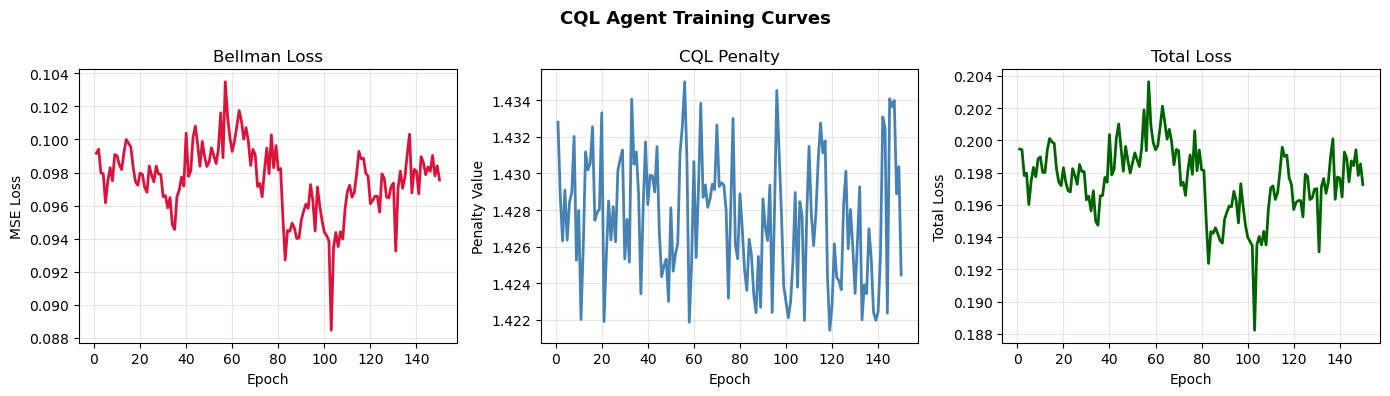

Final Bellman loss: 0.0976
Final CQL penalty:  1.4245
Final total loss:   0.1973


In [193]:
# ─────────────────────────────────────────────────────────────
# TRAINING CURVES
# ─────────────────────────────────────────────────────────────
# Plot the loss curves to verify training converged correctly.
#
# What healthy training looks like:
#   - Total loss decreases and stabilises
#   - Bellman loss decreases (agent is learning accurate Q-values)
#   - CQL penalty may increase slightly then stabilise
#     (this is normal — the penalty is doing its job)

epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, bellman_losses, color="crimson", linewidth=2)
axes[0].set_title("Bellman Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, cql_penalties, color="steelblue", linewidth=2)
axes[1].set_title("CQL Penalty")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Penalty Value")
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, total_losses, color="darkgreen", linewidth=2)
axes[2].set_title("Total Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Total Loss")
axes[2].grid(alpha=0.3)

plt.suptitle("CQL Agent Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cql_training_curves.png", dpi=150)
plt.show()

print(f"Final Bellman loss: {bellman_losses[-1]:.4f}")
print(f"Final CQL penalty:  {cql_penalties[-1]:.4f}")
print(f"Final total loss:   {total_losses[-1]:.4f}")

In [195]:
# ─────────────────────────────────────────────────────────────
# CQL POLICY — SELECT ACTIONS USING TRAINED Q-NETWORK
# ─────────────────────────────────────────────────────────────

def cql_policy(state: State, sim: SCDSimulator,
               rng: np.random.Generator) -> int:
    """
    Selects the action with the highest Q-value among safe actions.

    This implements the two-layer safety architecture:
      1. Neural network computes Q(s,a) for all 5 actions
      2. Safety checker filters to only safe actions
      3. Agent picks the safe action with highest Q-value

    Even if the network assigns high Q-values to unsafe actions,
    the safety checker ensures they are never selected.
    """
    # Convert state to tensor
    s_tensor = torch.FloatTensor(state.to_array()).unsqueeze(0).to(DEVICE)

    # Get Q-values from trained network
    with torch.no_grad():
        q_values = q_net(s_tensor).squeeze(0).numpy()

    # Get safe actions
    safe_actions = sim.get_safe_actions(state)

    # Select safe action with highest Q-value
    best_action = max(safe_actions, key=lambda a: q_values[a])
    return best_action


# ─────────────────────────────────────────────────────────────
# EVALUATE CQL AGENT
# ─────────────────────────────────────────────────────────────

print("Evaluating CQL agent (500 episodes)...\n")
cql_result = evaluate_policy(cql_policy, "CQL Agent", n_episodes=500)

print(f"  Mean pain:         {cql_result['mean_pain']}")
print(f"  Final pain:        {cql_result['final_pain']}")
print(f"  % at target:       {cql_result['pct_at_target']}%")
print(f"  Safety violations: {cql_result['safety_violations']}")
print(f"  Mean cum. dose:    {cql_result['mean_cum_dose']} mg")
print(f"  By type — mild: {cql_result['mean_pain_mild']}, "
      f"mod: {cql_result['mean_pain_mod']}, sev: {cql_result['mean_pain_sev']}")

# ─────────────────────────────────────────────────────────────
# FULL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────

all_results = baseline_results + [cql_result]

print("\n" + "=" * 65)
print(f"{'Policy':<22} {'MeanPain':>9} {'FinalPain':>10} "
      f"{'AtTarget%':>10} {'SafeViols':>10}")
print("=" * 65)
for r in all_results:
    marker = " ← CQL" if r["policy"] == "CQL Agent" else ""
    print(f"{r['policy']:<22} {r['mean_pain']:>9} {r['final_pain']:>10} "
          f"{r['pct_at_target']:>9}% {r['safety_violations']:>10}{marker}")
print("=" * 65)

Evaluating CQL agent (500 episodes)...

  Mean pain:         3.826
  Final pain:        3.573
  % at target:       37.9%
  Safety violations: 0
  Mean cum. dose:    33.61 mg
  By type — mild: 2.975, mod: 3.591, sev: 5.756

Policy                  MeanPain  FinalPain  AtTarget%  SafeViols
Random Policy              3.914      3.127      35.7%          0
Standard Protocol          4.252      4.069      18.9%          0
Reactive Heuristic         3.842      3.588      32.6%          0
CQL Agent                  3.826      3.573      37.9%          0 ← CQL


In [197]:
# ─────────────────────────────────────────────────────────────
# SPLIT-BASED EVALUATION — Validation and Test
# ─────────────────────────────────────────────────────────────
# Now that the agent is trained on the train split,
# we evaluate all four policies on validation and test sets
# separately. Validation results inform hyperparameter choice;
# test results are the final reportable numbers.

print("=" * 70)
print("VALIDATION SET EVALUATION (300 episodes)")
print("=" * 70)
val_results = []
for policy_fn, name in [
    (random_policy,             "Random Policy"),
    (standard_protocol_policy,  "Standard Protocol"),
    (reactive_heuristic_policy, "Reactive Heuristic"),
    (cql_policy,                "CQL Agent"),
]:
    r = evaluate_policy_on_split(policy_fn, name, val_episode_ids)
    val_results.append(r)
    marker = " ← CQL" if name == "CQL Agent" else ""
    print(f"  {name:<22} | Mean Pain: {r['mean_pain']:>5} | "
          f"At Target: {r['pct_at_target']:>5}% | "
          f"Safe Viols: {r['safety_violations']}{marker}")

print()
print("=" * 70)
print("TEST SET EVALUATION (300 episodes) — FINAL RESULTS")
print("=" * 70)
test_results = []
for policy_fn, name in [
    (random_policy,             "Random Policy"),
    (standard_protocol_policy,  "Standard Protocol"),
    (reactive_heuristic_policy, "Reactive Heuristic"),
    (cql_policy,                "CQL Agent"),
]:
    r = evaluate_policy_on_split(policy_fn, name, test_episode_ids)
    test_results.append(r)
    marker = " ← CQL" if name == "CQL Agent" else ""
    print(f"  {name:<22} | Mean Pain: {r['mean_pain']:>5} | "
          f"At Target: {r['pct_at_target']:>5}% | "
          f"Safe Viols: {r['safety_violations']}{marker}")

print()
print("=" * 70)
print("FINAL TEST RESULTS — DETAILED")
print("=" * 70)
print(f"{'Policy':<22} {'MeanPain':>9} {'FinalPain':>10} "
      f"{'AtTarget%':>10} {'SafeViols':>10} {'CumDose':>9}")
print("-" * 70)
for r in test_results:
    print(f"{r['policy']:<22} {r['mean_pain']:>9} {r['final_pain']:>10} "
          f"{r['pct_at_target']:>9}% {r['safety_violations']:>10} "
          f"{r['mean_cum_dose']:>8} mg")

VALIDATION SET EVALUATION (300 episodes)
  Random Policy          | Mean Pain: 4.003 | At Target:  32.8% | Safe Viols: 0
  Standard Protocol      | Mean Pain: 4.284 | At Target:  18.4% | Safe Viols: 0
  Reactive Heuristic     | Mean Pain: 3.901 | At Target:  30.9% | Safe Viols: 0
  CQL Agent              | Mean Pain: 3.825 | At Target:  36.0% | Safe Viols: 0 ← CQL

TEST SET EVALUATION (300 episodes) — FINAL RESULTS
  Random Policy          | Mean Pain: 3.993 | At Target:  35.4% | Safe Viols: 0
  Standard Protocol      | Mean Pain:  4.29 | At Target:  17.7% | Safe Viols: 0
  Reactive Heuristic     | Mean Pain: 3.922 | At Target:  30.5% | Safe Viols: 0
  CQL Agent              | Mean Pain: 3.829 | At Target:  36.9% | Safe Viols: 0 ← CQL

FINAL TEST RESULTS — DETAILED
Policy                  MeanPain  FinalPain  AtTarget%  SafeViols   CumDose
----------------------------------------------------------------------
Random Policy              3.993      3.268      35.4%          0    40.52 mg

In [211]:
# ─────────────────────────────────────────────────────────────
# MULTI-SEED EVALUATION
# ─────────────────────────────────────────────────────────────
# Train the CQL agent 5 times with different seeds and
# evaluate each on the test set. Reports mean ± SD across seeds,
# providing statistical robustness to the single-seed result.
#
# This addresses the "lucky seed" critique that single-run
# evaluations are vulnerable to. Standard practice in offline RL
# evaluation (Levine et al., 2020).

import copy

def train_cql_agent(seed: int, n_epochs: int = 150,
                    cql_alpha: float = 0.07,
                    lr: float = 3e-4,
                    batch_size: int = 256,
                    gamma: float = 0.99,
                    target_update: int = 100,
                    verbose: bool = False) -> QNetwork:
    """
    Trains a CQL agent from scratch with a given seed.
    Returns the trained Q-network.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    q_net_local      = QNetwork().to(DEVICE)
    target_net_local = QNetwork().to(DEVICE)
    target_net_local.load_state_dict(q_net_local.state_dict())
    target_net_local.eval()

    optimiser_local = optim.Adam(q_net_local.parameters(), lr=lr)
    n_samples       = len(states)
    n_batches       = n_samples // batch_size
    global_step     = 0

    for epoch in range(n_epochs):
        perm = torch.randperm(n_samples)
        for batch_idx in range(n_batches):
            idx = perm[batch_idx * batch_size : (batch_idx + 1) * batch_size]
            s, a, r, ns, d = states[idx], actions[idx], rewards[idx], next_states[idx], dones[idx]

            q_values = q_net_local(s)
            q_taken  = q_values.gather(1, a.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                next_q     = target_net_local(ns)
                next_q_max = next_q.max(dim=1).values
                target_q   = r + gamma * next_q_max * (1.0 - d)

            bellman_loss = nn.MSELoss()(q_taken, target_q)
            log_sum_exp  = torch.logsumexp(q_values, dim=1).mean()
            dataset_q    = q_taken.mean()
            cql_penalty  = log_sum_exp - dataset_q
            loss = bellman_loss + cql_alpha * cql_penalty

            optimiser_local.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_net_local.parameters(), max_norm=1.0)
            optimiser_local.step()

            global_step += 1
            if global_step % target_update == 0:
                target_net_local.load_state_dict(q_net_local.state_dict())

    return q_net_local


def evaluate_with_qnet(q_network, episode_ids):
    """Evaluate using a specific Q-network on a specific episode list."""
    def policy_fn(state, sim, rng):
        s_tensor = torch.FloatTensor(state.to_array()).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = q_network(s_tensor).squeeze(0).numpy()
        safe_actions = sim.get_safe_actions(state)
        return max(safe_actions, key=lambda a: q_values[a])
    return evaluate_policy_on_split(policy_fn, "CQL", episode_ids)


# Run multi-seed training and evaluation
SEEDS = [42, 123, 456, 789, 2024]
print(f"Multi-seed CQL evaluation across {len(SEEDS)} seeds...\n")

multi_seed_results = []
for i, seed in enumerate(SEEDS):
    print(f"  Seed {seed} ({i+1}/{len(SEEDS)})... ", end="", flush=True)
    trained_net = train_cql_agent(seed=seed, verbose=False)
    test_metrics = evaluate_with_qnet(trained_net, test_episode_ids)
    multi_seed_results.append(test_metrics)
    print(f"Mean pain: {test_metrics['mean_pain']}, "
          f"At target: {test_metrics['pct_at_target']}%, "
          f"Safe viols: {test_metrics['safety_violations']}")

# Aggregate
print("\n" + "=" * 70)
print("MULTI-SEED TEST RESULTS — CQL AGENT")
print("=" * 70)

metrics = ["mean_pain", "final_pain", "pct_at_target", "mean_cum_dose",
           "mean_pain_mild", "mean_pain_mod", "mean_pain_sev"]
labels  = ["Mean pain", "Final pain", "% at target", "Cum. dose (mg)",
           "Mean pain (mild)", "Mean pain (moderate)", "Mean pain (severe)"]

for m, lbl in zip(metrics, labels):
    vals = [r[m] for r in multi_seed_results]
    mean = np.mean(vals)
    sd   = np.std(vals)
    print(f"  {lbl:<22} {mean:>7.3f} \u00b1 {sd:.3f}")

total_safety_viols = sum(r["safety_violations"] for r in multi_seed_results)
print(f"  {'Safety violations':<22} {total_safety_viols} (across all {len(SEEDS)} seeds)")

Multi-seed CQL evaluation across 5 seeds...

  Seed 42 (1/5)... Mean pain: 3.847, At target: 33.7%, Safe viols: 0
  Seed 123 (2/5)... Mean pain: 4.18, At target: 25.7%, Safe viols: 0
  Seed 456 (3/5)... Mean pain: 4.053, At target: 23.0%, Safe viols: 0
  Seed 789 (4/5)... Mean pain: 3.929, At target: 28.7%, Safe viols: 0
  Seed 2024 (5/5)... Mean pain: 3.76, At target: 33.5%, Safe viols: 0

MULTI-SEED TEST RESULTS — CQL AGENT
  Mean pain                3.954 ± 0.149
  Final pain               3.754 ± 0.100
  % at target             28.920 ± 4.226
  Cum. dose (mg)          32.890 ± 1.850
  Mean pain (mild)         2.939 ± 0.076
  Mean pain (moderate)     4.077 ± 0.234
  Mean pain (severe)       5.747 ± 0.207
  Safety violations      0 (across all 5 seeds)


In [221]:
# ─────────────────────────────────────────────────────────────
# RESULTS VISUALISATION — CHAPTER 4 PLOTS
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Compile final results from the test set evaluation + multi-seed CQL
# Test set baseline numbers (from your earlier evaluation)
final_results = {
    "Random Policy":      {"mean_pain": 3.993, "mean_pain_sd": 0.0,
                           "final_pain": 3.268, "pct_target": 35.4,
                           "pct_target_sd": 0.0, "cum_dose": 40.52,
                           "mild": 2.602, "mod": 3.784, "sev": 5.801,
                           "safe_viols": 0},
    "Standard Protocol":  {"mean_pain": 4.290, "mean_pain_sd": 0.0,
                           "final_pain": 4.067, "pct_target": 17.7,
                           "pct_target_sd": 0.0, "cum_dose": 29.50,
                           "mild": 3.167, "mod": 4.575, "sev": 5.750,
                           "safe_viols": 0},
    "Reactive Heuristic": {"mean_pain": 3.922, "mean_pain_sd": 0.0,
                           "final_pain": 3.649, "pct_target": 30.5,
                           "pct_target_sd": 0.0, "cum_dose": 35.65,
                           "mild": 2.809, "mod": 4.165, "sev": 5.496,
                           "safe_viols": 0},
    "CQL Agent":          {"mean_pain": 3.954, "mean_pain_sd": 0.149,
                           "final_pain": 3.754, "pct_target": 28.92,
                           "pct_target_sd": 4.226, "cum_dose": 32.89,
                           "mild": 2.939, "mod": 4.077, "sev": 5.747,
                           "safe_viols": 0}
}

policies = list(final_results.keys())
colours  = ["#888888", "#d62728", "#ff7f0e", "#2ca02c"]  # grey, red, orange, green

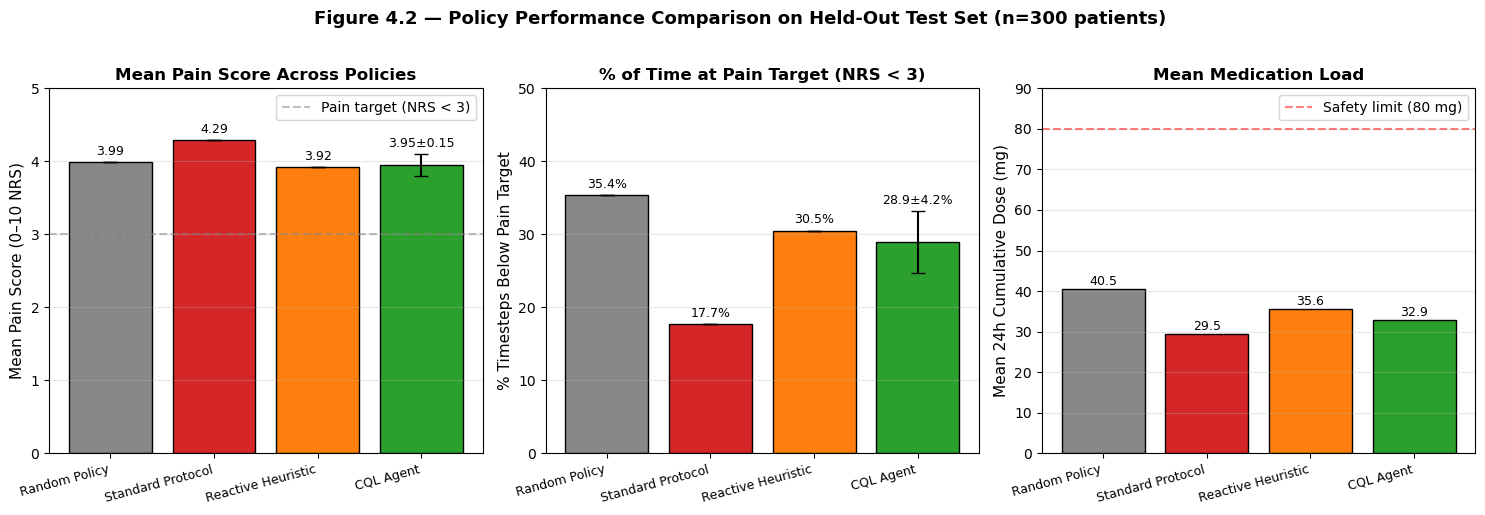

Saved: figure_4_2_policy_comparison.png


In [223]:
# ─────────────────────────────────────────────────────────────
# FIGURE 1: Overall Performance Comparison
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Mean Pain
mean_pains = [final_results[p]["mean_pain"] for p in policies]
sd_pains   = [final_results[p]["mean_pain_sd"] for p in policies]
bars = axes[0].bar(range(len(policies)), mean_pains, yerr=sd_pains,
                    color=colours, edgecolor="black", capsize=5)
axes[0].axhline(y=3.0, color="grey", linestyle="--", alpha=0.5,
                label="Pain target (NRS < 3)")
axes[0].set_ylabel("Mean Pain Score (0–10 NRS)", fontsize=11)
axes[0].set_title("Mean Pain Score Across Policies", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(len(policies)))
axes[0].set_xticklabels(policies, rotation=15, ha="right", fontsize=9)
axes[0].set_ylim(0, 5)
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", alpha=0.3)
for i, (mp, sd) in enumerate(zip(mean_pains, sd_pains)):
    label = f"{mp:.2f}" if sd == 0 else f"{mp:.2f}±{sd:.2f}"
    axes[0].text(i, mp + sd + 0.1, label, ha="center", fontsize=9)

# Subplot 2: % at Target
pct_targets = [final_results[p]["pct_target"] for p in policies]
sd_targets  = [final_results[p]["pct_target_sd"] for p in policies]
axes[1].bar(range(len(policies)), pct_targets, yerr=sd_targets,
            color=colours, edgecolor="black", capsize=5)
axes[1].set_ylabel("% Timesteps Below Pain Target", fontsize=11)
axes[1].set_title("% of Time at Pain Target (NRS < 3)", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(len(policies)))
axes[1].set_xticklabels(policies, rotation=15, ha="right", fontsize=9)
axes[1].set_ylim(0, 50)
axes[1].grid(axis="y", alpha=0.3)
for i, (pt, sd) in enumerate(zip(pct_targets, sd_targets)):
    label = f"{pt:.1f}%" if sd == 0 else f"{pt:.1f}±{sd:.1f}%"
    axes[1].text(i, pt + sd + 1, label, ha="center", fontsize=9)

# Subplot 3: Cumulative Dose
cum_doses = [final_results[p]["cum_dose"] for p in policies]
axes[2].bar(range(len(policies)), cum_doses,
            color=colours, edgecolor="black")
axes[2].axhline(y=80, color="red", linestyle="--", alpha=0.5,
                label="Safety limit (80 mg)")
axes[2].set_ylabel("Mean 24h Cumulative Dose (mg)", fontsize=11)
axes[2].set_title("Mean Medication Load", fontsize=12, fontweight="bold")
axes[2].set_xticks(range(len(policies)))
axes[2].set_xticklabels(policies, rotation=15, ha="right", fontsize=9)
axes[2].set_ylim(0, 90)
axes[2].legend(loc="upper right")
axes[2].grid(axis="y", alpha=0.3)
for i, cd in enumerate(cum_doses):
    axes[2].text(i, cd + 1, f"{cd:.1f}", ha="center", fontsize=9)

plt.suptitle("Figure 4.2 — Policy Performance Comparison on Held-Out Test Set (n=300 patients)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure_4_2_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure_4_2_policy_comparison.png")

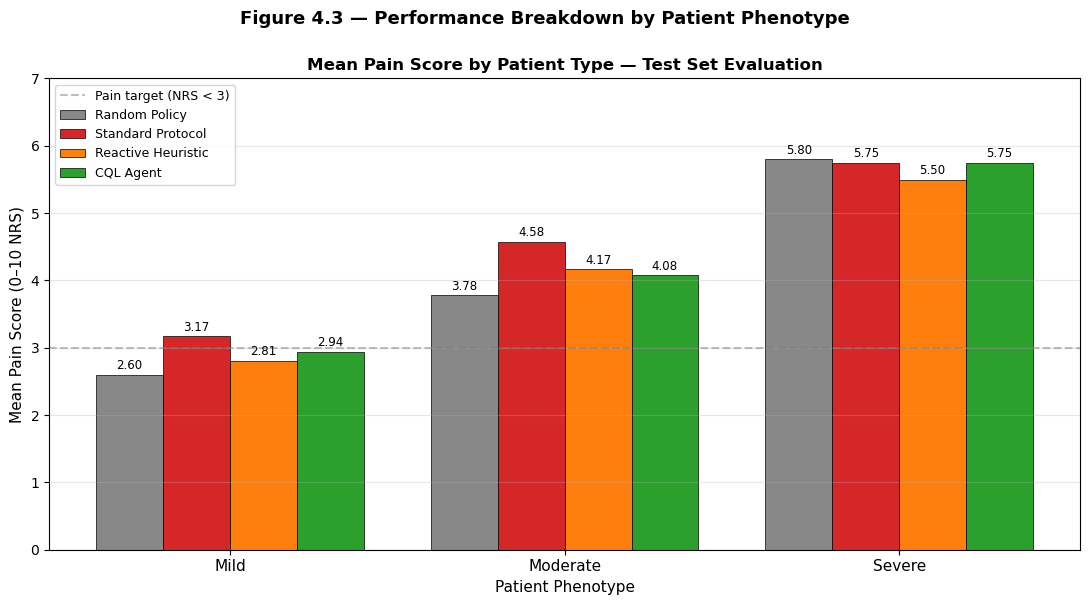

Saved: figure_4_3_per_patient_type.png


In [225]:
# ─────────────────────────────────────────────────────────────
# FIGURE 4.3 — Per-Patient-Type Breakdown
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 6))

patient_types = ["Mild", "Moderate", "Severe"]
type_keys     = ["mild", "mod", "sev"]
n_policies    = len(policies)
bar_width     = 0.20
x             = np.arange(len(patient_types))

for i, policy in enumerate(policies):
    values = [final_results[policy][k] for k in type_keys]
    offset = (i - n_policies / 2 + 0.5) * bar_width
    ax.bar(x + offset, values, bar_width,
           label=policy, color=colours[i], edgecolor="black", linewidth=0.5)

    # Annotate values above bars
    for xi, v in zip(x + offset, values):
        ax.text(xi, v + 0.08, f"{v:.2f}", ha="center", fontsize=8.5)

ax.axhline(y=3.0, color="grey", linestyle="--", alpha=0.5,
           label="Pain target (NRS < 3)")
ax.set_xlabel("Patient Phenotype", fontsize=11)
ax.set_ylabel("Mean Pain Score (0–10 NRS)", fontsize=11)
ax.set_title("Mean Pain Score by Patient Type — Test Set Evaluation",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(patient_types, fontsize=11)
ax.set_ylim(0, 7)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Figure 4.3 — Performance Breakdown by Patient Phenotype",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("figure_4_3_per_patient_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure_4_3_per_patient_type.png")

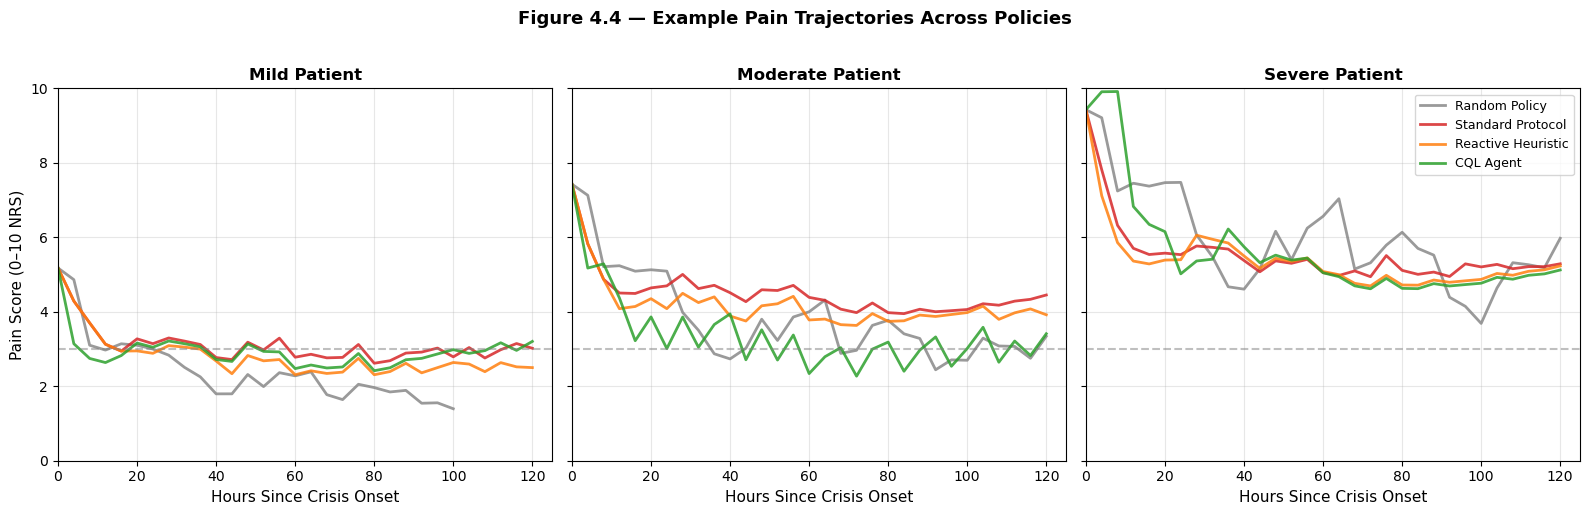

Saved: figure_4_4_trajectories.png


In [227]:
# ─────────────────────────────────────────────────────────────
# FIGURE 4.4 — Example Patient Trajectories
# ─────────────────────────────────────────────────────────────
# For each patient phenotype, run all four policies on the SAME
# fixed patient and plot pain trajectories side-by-side.

# Build representative patients (midpoints of each phenotype's range)
representative_patients = {
    "Mild": PatientProfile(
        patient_id=999, patient_type=0,
        pain_sensitivity=0.45, drug_response=0.65,
        tolerance_rate=0.010, tolerance_decay=0.045,
        baseline_pain=4.0
    ),
    "Moderate": PatientProfile(
        patient_id=999, patient_type=1,
        pain_sensitivity=0.65, drug_response=0.48,
        tolerance_rate=0.018, tolerance_decay=0.030,
        baseline_pain=6.25
    ),
    "Severe": PatientProfile(
        patient_id=999, patient_type=2,
        pain_sensitivity=0.85, drug_response=0.32,
        tolerance_rate=0.025, tolerance_decay=0.020,
        baseline_pain=8.25
    ),
}

policy_fns_for_traj = {
    "Random Policy":      random_policy,
    "Standard Protocol":  standard_protocol_policy,
    "Reactive Heuristic": reactive_heuristic_policy,
    "CQL Agent":          cql_policy,
}
policy_colours = {"Random Policy": "#888888", "Standard Protocol": "#d62728",
                  "Reactive Heuristic": "#ff7f0e", "CQL Agent": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for col, (ptype_name, profile) in enumerate(representative_patients.items()):
    ax = axes[col]
    for policy_name, policy_fn in policy_fns_for_traj.items():
        # Use the same seed for all policies so the same patient is faced
        sim = SCDSimulator(seed=2024)
        state = sim.reset(patient=profile)
        rng = np.random.default_rng(2024)

        pain_traj = [state.pain_score]
        hours     = [0]

        done = False
        while not done:
            action = policy_fn(state, sim, rng)
            state, _, done, _ = sim.step(action)
            pain_traj.append(state.pain_score)
            hours.append(state.time_since_crisis)

        ax.plot(hours, pain_traj, color=policy_colours[policy_name],
                linewidth=2.0, label=policy_name, alpha=0.85)

    ax.axhline(y=3.0, color="grey", linestyle="--", alpha=0.5)
    ax.set_xlabel("Hours Since Crisis Onset", fontsize=11)
    if col == 0:
        ax.set_ylabel("Pain Score (0–10 NRS)", fontsize=11)
    ax.set_title(f"{ptype_name} Patient", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 10)
    ax.set_xlim(0, 125)
    ax.grid(alpha=0.3)
    if col == 2:
        ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Figure 4.4 — Example Pain Trajectories Across Policies",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure_4_4_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure_4_4_trajectories.png")